# Geometry and meshing of NACA 4 and 5 digit airfoils

In this tutorial we will generate an airfoil mesh using `mikfoil.meshing` which can be used either as a standalone meshing tool or together with the simulation module. In this and the next tutorial we will use the standalone meshing.



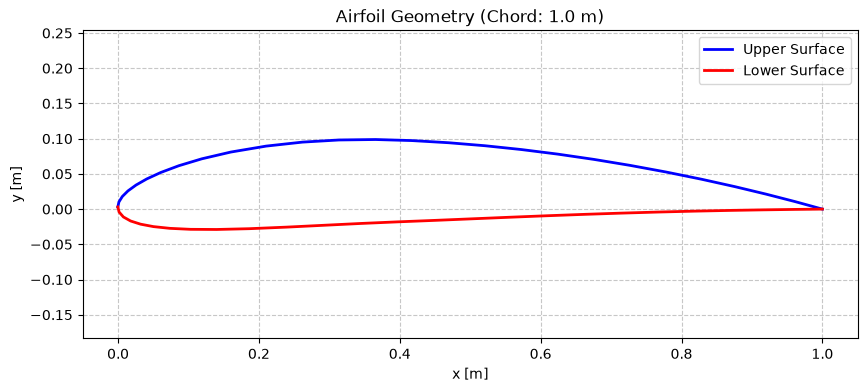

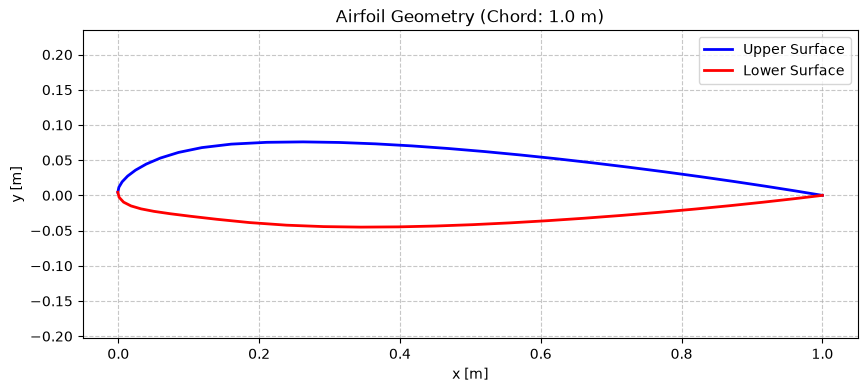

In [1]:
from mikfoil.geometry import create_airfoil, plot_airfoil

# First let's create the airfoil geometries
naca4_geom = create_airfoil("4412")
naca5_geom = create_airfoil("23012")

# We can plot them to see the generated airfoils
plot_airfoil(naca4_geom, show=True)
plot_airfoil(naca5_geom, show=True, filepath="data/naca23012.png")

Using MikFoil we can generate standard NACA 4-digit and 5-digit airfoil. If you want to find out what equations are used for generating those airfoils you can read more about them [here](https://en.wikipedia.org/wiki/NACA_airfoil).




In [2]:
from mikfoil.case import MeshConfig

# Let's create a config, we can see all the parameters that can be customised in mesh generation
default_config = MeshConfig(
    use_normals=True, 
    fineness=1.0,
    domain_radius=10.0,
    wake_length=10.0,
    chord=1.0,
    first_layer_height=0.001,

    s_le=0.005,
    s_mid=0.04,
    s_te=0.03,
    radial_growth_rate=1.03,
    wake_growth_rate=1.05
)

#This config uses default values and could be created as well simply by calling
# default_config = MeshConfig()


MikFoil uses config like dataclasses to control the program behaviour, in this case mesh generation. The most important parameter is `fineness`, which purpose is to allow us to control the mesh with a single parameter that can be changed without too much thinking if we decide that a finer or coarser mesh is needed.

It does that by controlling the multipliers of sizes on the leading edge `s_le`, 25% chord `s_mid`, and trailing edge `s_te`. The default values were set by trial and error and they are by no means ideal for every application, so feel free to edit them.

In [3]:
from mikfoil.meshing import generate_mesh
from mikfoil.meshing.mesh_visualisation import visualize_mesh_interactive

#In this step we generate the mesh
mesh = generate_mesh(naca5_geom, default_config)

# We can visualize the mesh interactively using Pyvista
visualize_mesh_interactive(mesh)


Widget(value='<iframe src="http://localhost:49609/index.html?ui=P_0x14239b48980_0&reconnect=auto" class="pyvis…

In this step we created a mapped mesh of the airfoil NACA 4412. This type of mesh is often called a C-grid. Please refer to this [article](https://cfd.university/learn/10-key-concepts-everyone-must-understand-in-cfd/mesh-generation-in-cfd-all-you-need-to-know-in-one-article) if you want to know more about mesh types in airfoil CFD.

In [4]:
# By adjusting MeshConfig we can get a different mesh
new_config = MeshConfig(
    fineness=2, 
    domain_radius=5,
    use_normals=False
)

# Let's generate the new mesh
new_naca4_geom = create_airfoil("NACA4412", new_config)

# Let's generate the new mesh
new_mesh = generate_mesh(new_naca4_geom, new_config)

# And plot it to see the difference
visualize_mesh_interactive(new_mesh)


Widget(value='<iframe src="http://localhost:49609/index.html?ui=P_0x1423e09b390_1&reconnect=auto" class="pyvis…

We can modify the mesh parameters by changing their respective values in the `MeshConfig` object we are passing. In this case we increased the fineness of the mesh, decreased the radius and did not impose the mesh to be normal to airfoil surface.